# Chapter B · Notebook 04 — Assembling the six-league dataset

One uniform loader (`brasileirao.leagues`) pulls results **and** closing odds from football-data.co.uk for all six leagues into a single canonical table. This notebook downloads the candidate window (2012–2025), checks each league-season against its full double-round-robin fixture count, confirms the most recent season complete in **all six** leagues, and caches the matched table to `data/processed/leagues.parquet` for Notebook 05.

Season labelling follows the calendar year a season *starts*: Brazil's calendar-year 2012 and Europe's 2012/13 are both `2012`, so the window is directly comparable across leagues.

In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt

from brasileirao import leagues, plotting
from brasileirao.paths import PROCESSED

plotting.style()
# football-data mixes date formats across its two file families; the
# loader parses both correctly, we just silence the inference warning.
warnings.filterwarnings("ignore", message="Could not infer format")

## Download and assemble the candidate window

`load_all` downloads (and caches under `data/raw/`) every league-season in the candidate range, normalises each source layout into the canonical schema, and derives `outcome` from goals (never trusting the file's own result column).

In [2]:
CANDIDATE_SEASONS = range(2012, 2026)   # widened; the coverage check trims it
raw = leagues.load_all(CANDIDATE_SEASONS)
print(f"Loaded {len(raw):,} matches across {raw['league'].nunique()} leagues "
      f"and seasons {raw['season'].min()}-{raw['season'].max()}.")

Loaded 30,560 matches across 6 leagues and seasons 2012-2025.


## Fixture-count coverage check

A complete season is a full double round-robin. Most leagues are 20 teams (380 matches); the **Bundesliga** is an 18-team league (306) throughout, and **Ligue 1** dropped from 20 to 18 teams from 2023/24 — so it is 380 through 2022 and 306 from 2023. The expectation is therefore a function of *both* league and season, not a per-league constant.

In [3]:
def expected(league: str, season: int) -> int:
    """Full double-round-robin fixture count for a (league, season)."""
    if league == "Bundesliga":
        return 306                      # 18 teams throughout
    if league == "Ligue 1":
        return 306 if season >= 2023 else 380   # cut to 18 teams from 2023/24
    return 380                          # 20-team leagues

counts = raw.groupby(["league", "season"]).size().rename("n").reset_index()
pivot = counts.pivot(index="season", columns="league", values="n")
print("Match counts per league x season:")
print(pivot.fillna(0).astype(int))

Match counts per league x season:
league  Brasileirao  Bundesliga  La Liga  Ligue 1  Premier League  Serie A
season                                                                    
2012            380         306      380      380             380      380
2013            380         306      380      380             380      380
2014            380         306      380      380             380      380
2015            380         306      380      380             380      380
2016            379         306      380      380             380      380
2017            380         306      380      380             380      380
2018            380         306      380      380             380      380
2019            380         306      380      279             380      380
2020            380         306      380      380             380      380
2021            380         306      380      380             380      380
2022            380         306      380      380             380 

In [4]:
# Report every (league, season) short of its full fixture list.
shortfalls = []
for season in pivot.index:
    for lg in pivot.columns:
        n = pivot.loc[season, lg]
        if pd.notna(n) and n < expected(lg, season):
            shortfalls.append((lg, int(season), int(n), expected(lg, season)))

print("Seasons below full fixture count:")
for lg, s, n, e in shortfalls:
    print(f"  {lg} {s}: {n}/{e}")

print(
    "\nData-quality notes on the two shortfalls (both real, not defects):\n"
    "  - Brasileirao 2016 (379/380): Chapecoense vs Atletico-MG (11 Dec 2016) "
    "was annulled after the LaMia air disaster - one genuinely unplayed "
    "fixture. Off by one; the season is retained everywhere.\n"
    "  - Ligue 1 2019 (279/380): the 2019/20 season was cancelled outright in "
    "April 2020 for COVID-19 (the only big-five league not to resume). It is "
    "materially truncated, so Notebook 05 keeps it for match-level metrics but "
    "excludes it from season-level table metrics (Noll-Scully, race "
    "decidedness), whose standings shape assumes a full schedule."
)

Seasons below full fixture count:
  Brasileirao 2016: 379/380
  Ligue 1 2019: 279/380

Data-quality notes on the two shortfalls (both real, not defects):
  - Brasileirao 2016 (379/380): Chapecoense vs Atletico-MG (11 Dec 2016) was annulled after the LaMia air disaster - one genuinely unplayed fixture. Off by one; the season is retained everywhere.
  - Ligue 1 2019 (279/380): the 2019/20 season was cancelled outright in April 2020 for COVID-19 (the only big-five league not to resume). It is materially truncated, so Notebook 05 keeps it for match-level metrics but excludes it from season-level table metrics (Noll-Scully, race decidedness), whose standings shape assumes a full schedule.


In [5]:
# A season is 'complete in all six' only if every league is present AND at
# its full fixture count. This gates LAST_SEASON; the matched window is then
# the contiguous range 2012..LAST_SEASON, so interior near-complete seasons
# (e.g. Brazil 2016) are retained rather than dropped over one annulled game.
def season_complete(season: int) -> bool:
    row = pivot.loc[season]
    if not row.notna().all():
        return False
    return all(row[lg] == expected(lg, season) for lg in pivot.columns)

complete_seasons = [int(s) for s in pivot.index if s >= 2012 and season_complete(s)]
LAST_SEASON = max(complete_seasons)
print("Seasons complete in all six leagues:", complete_seasons)
print("LAST_SEASON =", LAST_SEASON)

Seasons complete in all six leagues: [2012, 2013, 2014, 2015, 2017, 2018, 2020, 2021, 2022, 2023, 2024, 2025]
LAST_SEASON = 2025


In [6]:
window = range(2012, LAST_SEASON + 1)
df = raw[raw.season.isin(list(window))].reset_index(drop=True)
df.to_parquet(PROCESSED / "leagues.parquet", index=False)
print(f"Wrote {len(df):,} matches over {LAST_SEASON - 2012 + 1} seasons "
      f"(2012-{LAST_SEASON}) to data/processed/leagues.parquet")

Wrote 30,560 matches over 14 seasons (2012-2025) to data/processed/leagues.parquet


## Odds coverage

The market benchmark in Notebook 05 can only be computed where closing odds exist. Coverage is near-complete for every league, but the exact share matters when reading the market log-loss comparison.

In [7]:
cov = (df.assign(has_odds=df[["odds_h", "odds_d", "odds_a"]].notna().all(axis=1))
       .groupby("league")["has_odds"].mean().sort_values())
print("Odds coverage (share of rows with H/D/A odds):")
print(cov.round(3))

Odds coverage (share of rows with H/D/A odds):
league
Bundesliga        0.963
La Liga           0.964
Serie A           0.965
Premier League    0.968
Ligue 1           0.969
Brasileirao       0.992
Name: has_odds, dtype: float64


## Matched-sample size by league

Bundesliga and post-2022 Ligue 1 field 18 teams, so they contribute fewer matches than the 20-team leagues — a real structural difference the metrics in Notebook 05 must not mistake for anything else.

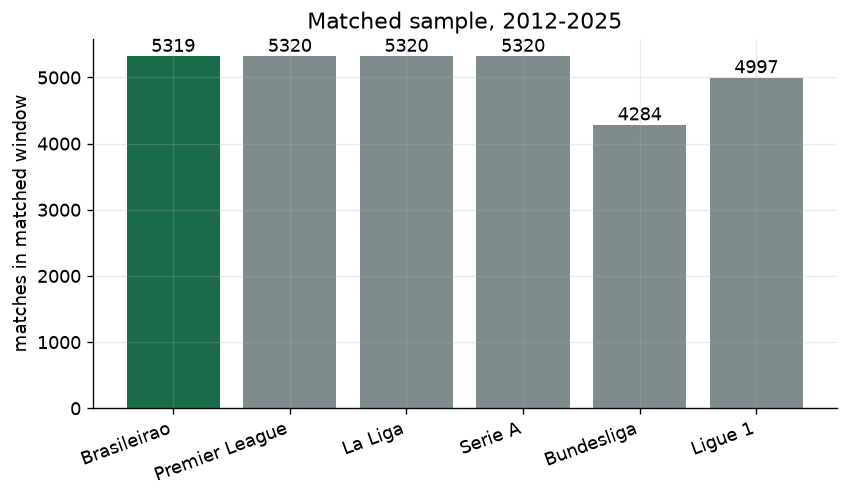

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
order = ["Brasileirao", "Premier League", "La Liga", "Serie A",
         "Bundesliga", "Ligue 1"]
matches_per_league = df.groupby("league").size().reindex(order)
bars = ax.bar(order, matches_per_league,
              color=[plotting.COLORS["main"]] + [plotting.COLORS["muted"]] * 5)
ax.bar_label(bars, fmt="%d")
ax.set(ylabel="matches in matched window",
       title=f"Matched sample, 2012-{LAST_SEASON}")
plt.xticks(rotation=20, ha="right")
plotting.save(fig, "league_coverage")
plt.show()